# YOLO Training for H. pylori Detection in Gastric Biopsy Patches


## 1. Setup and Installation

In [1]:
# Install required packages
!pip install ultralytics --break-system-packages
!pip install albumentations --break-system-packages
!pip install scikit-learn --break-system-packages
!pip install opencv-python --break-system-packages
!pip install matplotlib seaborn --break-system-packages
!pip install tqdm

In [2]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import yaml

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Organization and Analysis

In [3]:
# Define paths
PATCHES_DIR = Path("patches")
ANNOTATIONS_DIR = Path("annotation")
OUTPUT_DIR = Path("yolo_dataset")

# Check if directories exist
assert PATCHES_DIR.exists(), f"Patches directory not found: {PATCHES_DIR}"
assert ANNOTATIONS_DIR.exists(), f"Annotations directory not found: {ANNOTATIONS_DIR}"

print(f"✓ Patches directory: {PATCHES_DIR}")
print(f"✓ Annotations directory: {ANNOTATIONS_DIR}")
print(f"✓ Output directory will be: {OUTPUT_DIR}")

✓ Patches directory: patches
✓ Annotations directory: annotation
✓ Output directory will be: yolo_dataset


In [4]:
def analyze_dataset():
    """
    Analyze the dataset to understand:
    - Total patches
    - Patches with annotations (positive + negative)
    - Patches without annotations
    - Distribution of bounding boxes
    """
    # Get all image patches
    image_extensions = ['.png', '.jpg', '.jpeg']
    all_patches = [f for f in PATCHES_DIR.iterdir() 
                   if f.suffix.lower() in image_extensions]
    
    # Get all annotation files
    all_annotations = list(ANNOTATIONS_DIR.glob("*.txt"))
    
    # Create mapping
    patches_with_annot = []
    patches_without_annot = []
    positive_patches = []  # patches with H. pylori (non-empty annotation files)
    negative_patches = []  # patches with empty annotation files
    
    total_bboxes = 0
    bbox_sizes = []
    
    for patch in tqdm(all_patches, desc="Analyzing dataset"):
        patch_name = patch.stem
        annot_file = ANNOTATIONS_DIR / f"{patch_name}.txt"
        
        if annot_file.exists():
            patches_with_annot.append(patch)
            
            # Read annotation file
            with open(annot_file, 'r') as f:
                lines = f.readlines()
                lines = [l.strip() for l in lines if l.strip()]
            
            if lines:  # Has bounding boxes
                positive_patches.append(patch)
                total_bboxes += len(lines)
                
                # Parse bbox sizes
                for line in lines:
                    parts = line.split()
                    if len(parts) >= 5:
                        w, h = float(parts[3]), float(parts[4])
                        bbox_sizes.append((w, h))
            else:  # Empty annotation file (explicit negative)
                negative_patches.append(patch)
        else:
            patches_without_annot.append(patch)
    
    # Print statistics
    print("\n" + "="*60)
    print("DATASET STATISTICS")
    print("="*60)
    print(f"Total patches: {len(all_patches)}")
    print(f"\nPatches with annotation files: {len(patches_with_annot)} ({len(patches_with_annot)/len(all_patches)*100:.1f}%)")
    print(f"  - Positive patches (with H. pylori): {len(positive_patches)} ({len(positive_patches)/len(all_patches)*100:.1f}%)")
    print(f"  - Negative patches (explicit): {len(negative_patches)} ({len(negative_patches)/len(all_patches)*100:.1f}%)")
    print(f"\nPatches without annotation files: {len(patches_without_annot)} ({len(patches_without_annot)/len(all_patches)*100:.1f}%)")
    print(f"  (These will be treated as negatives)")
    print(f"\nTotal bounding boxes: {total_bboxes}")
    print(f"Average boxes per positive patch: {total_bboxes/len(positive_patches) if positive_patches else 0:.2f}")
    
    if bbox_sizes:
        widths = [w for w, h in bbox_sizes]
        heights = [h for w, h in bbox_sizes]
        print(f"\nBounding box statistics (normalized):")
        print(f"  Width:  mean={np.mean(widths):.3f}, std={np.std(widths):.3f}, min={np.min(widths):.3f}, max={np.max(widths):.3f}")
        print(f"  Height: mean={np.mean(heights):.3f}, std={np.std(heights):.3f}, min={np.min(heights):.3f}, max={np.max(heights):.3f}")
    
    print("="*60 + "\n")
    
    return {
        'all_patches': all_patches,
        'positive_patches': positive_patches,
        'negative_patches': negative_patches,
        'patches_without_annot': patches_without_annot,
        'total_bboxes': total_bboxes,
        'bbox_sizes': bbox_sizes
    }

# Analyze dataset
dataset_info = analyze_dataset()

Analyzing dataset: 100%|█████████████████| 2602/2602 [00:00<00:00, 31616.97it/s]


DATASET STATISTICS
Total patches: 2602

Patches with annotation files: 2602 (100.0%)
  - Positive patches (with H. pylori): 310 (11.9%)
  - Negative patches (explicit): 2292 (88.1%)

Patches without annotation files: 0 (0.0%)
  (These will be treated as negatives)

Total bounding boxes: 401
Average boxes per positive patch: 1.29

Bounding box statistics (normalized):
  Width:  mean=0.288, std=0.148, min=0.004, max=0.893
  Height: mean=0.251, std=0.116, min=0.010, max=0.828



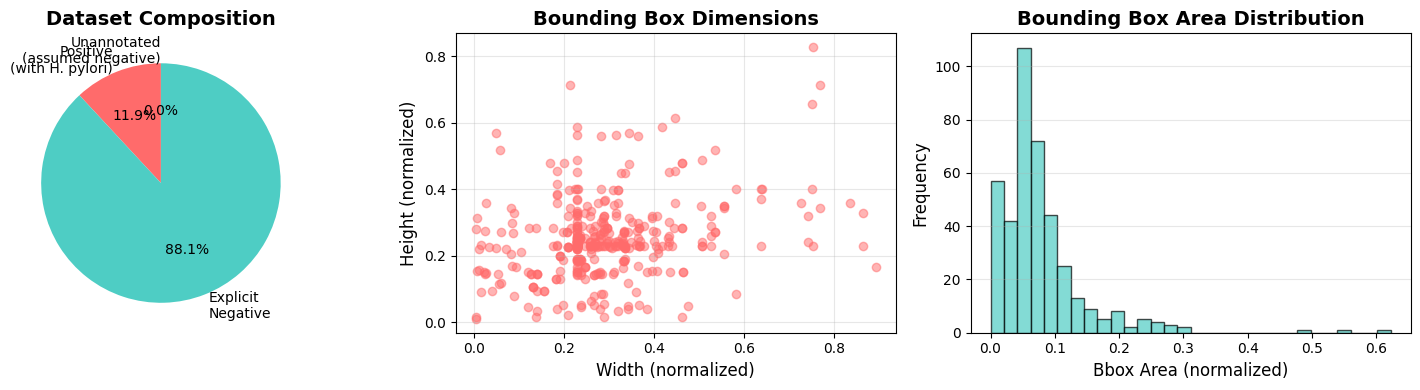

✓ Visualization saved as 'dataset_analysis.png'


In [5]:
# Visualize some statistics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pie chart of dataset composition
labels = ['Positive\n(with H. pylori)', 'Explicit\nNegative', 'Unannotated\n(assumed negative)']
sizes = [
    len(dataset_info['positive_patches']),
    len(dataset_info['negative_patches']),
    len(dataset_info['patches_without_annot'])
]
colors = ['#ff6b6b', '#4ecdc4', '#95e1d3']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Dataset Composition', fontsize=14, fontweight='bold')

# Bbox size distribution
if dataset_info['bbox_sizes']:
    widths = [w for w, h in dataset_info['bbox_sizes']]
    heights = [h for w, h in dataset_info['bbox_sizes']]
    
    axes[1].scatter(widths, heights, alpha=0.5, c='#ff6b6b')
    axes[1].set_xlabel('Width (normalized)', fontsize=12)
    axes[1].set_ylabel('Height (normalized)', fontsize=12)
    axes[1].set_title('Bounding Box Dimensions', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Histogram of areas
    areas = [w * h for w, h in dataset_info['bbox_sizes']]
    axes[2].hist(areas, bins=30, color='#4ecdc4', alpha=0.7, edgecolor='black')
    axes[2].set_xlabel('Bbox Area (normalized)', fontsize=12)
    axes[2].set_ylabel('Frequency', fontsize=12)
    axes[2].set_title('Bounding Box Area Distribution', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'dataset_analysis.png'")

## 3. Visualize Sample Patches

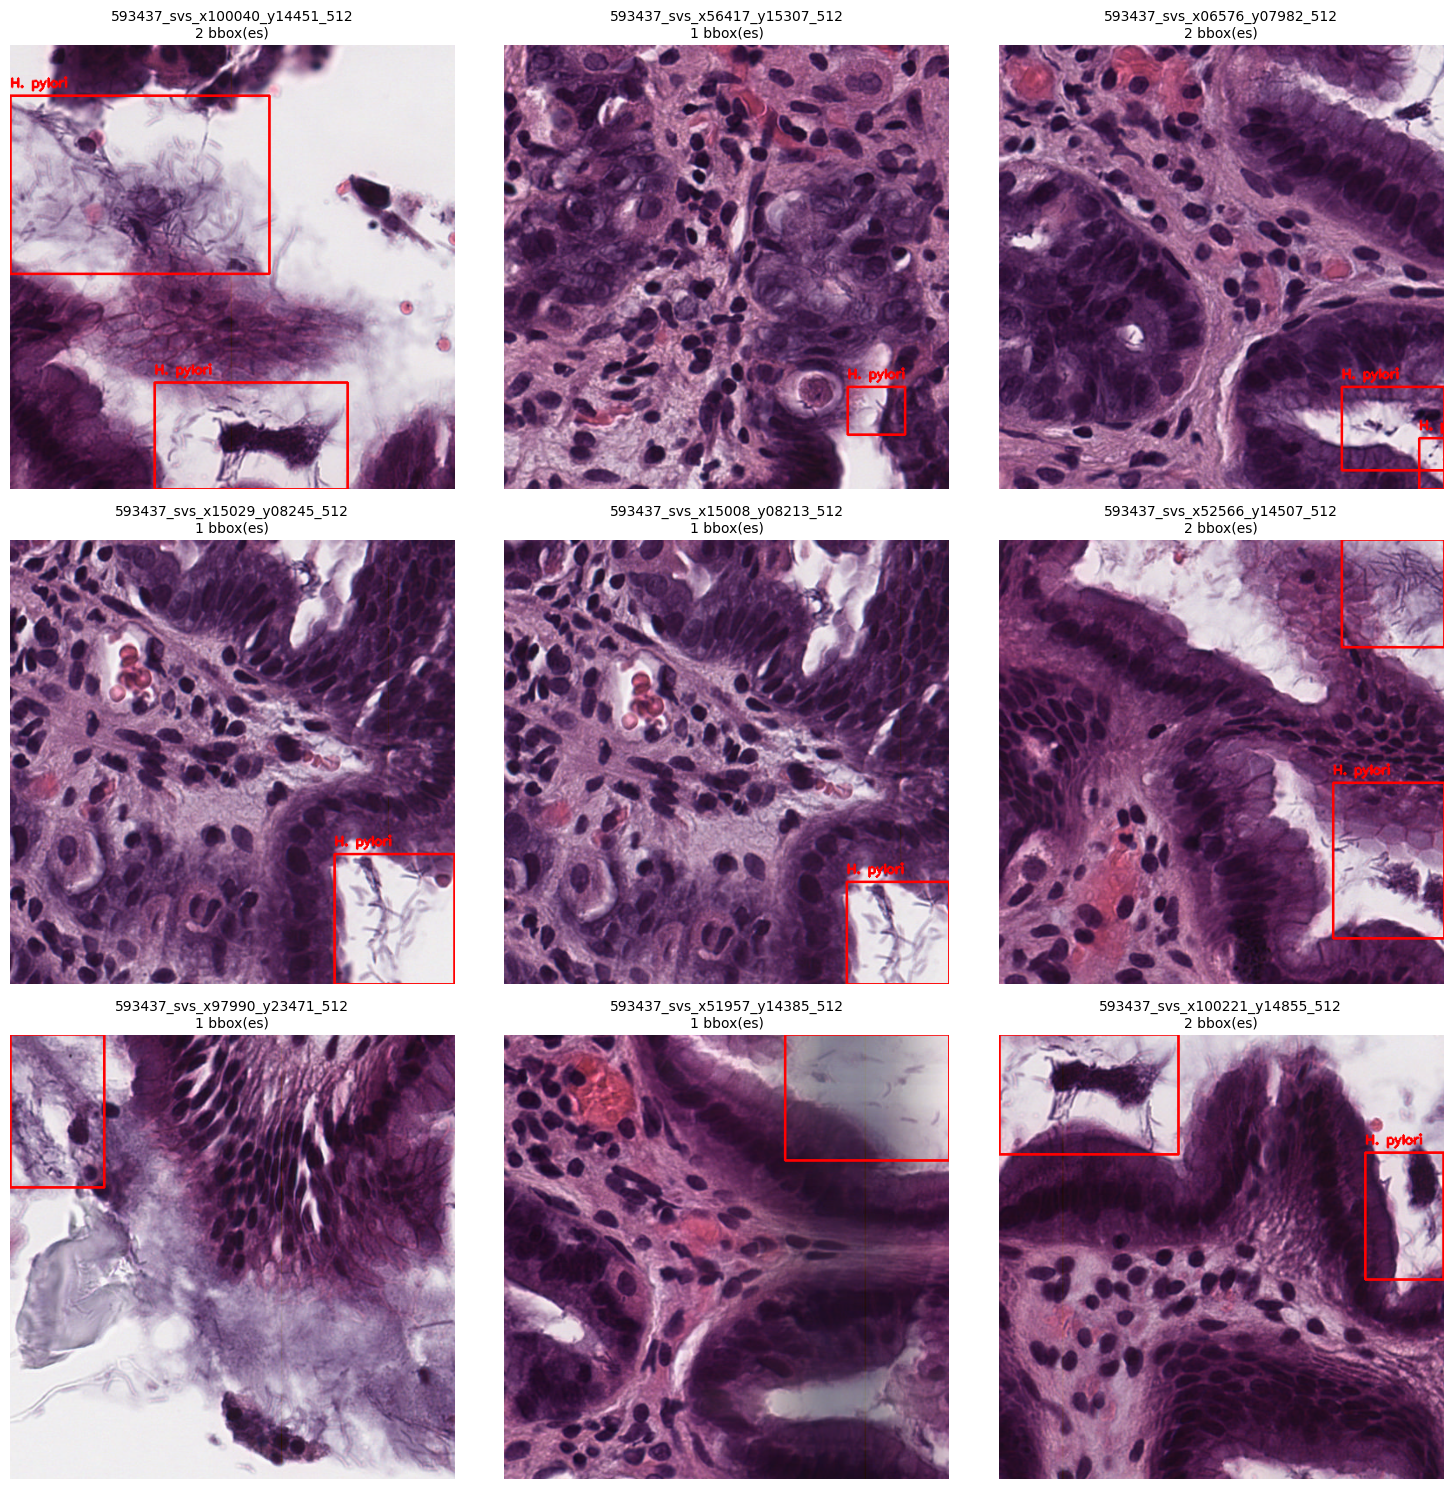

✓ Sample visualizations saved as 'sample_annotations.png'


In [6]:
def visualize_patches_with_annotations(num_samples=6):
    """
    Visualize sample patches with their annotations
    """
    positive_patches = dataset_info['positive_patches']
    
    if not positive_patches:
        print("No positive patches to visualize!")
        return
    
    samples = random.sample(positive_patches, min(num_samples, len(positive_patches)))
    
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    # Fix: Properly handle axes for different subplot configurations
    if rows == 1 and cols == 1:
        axes = [axes]  # Single subplot
    elif rows == 1 or cols == 1:
        axes = axes.flatten()  # Single row or column
    else:
        axes = axes.flatten()  # Multiple rows and columns
    
    for idx, patch_path in enumerate(samples):
        # Read image
        img = cv2.imread(str(patch_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Read annotations
        annot_path = ANNOTATIONS_DIR / f"{patch_path.stem}.txt"
        
        lines = []  # Initialize lines here to avoid reference error
        if annot_path.exists():
            with open(annot_path, 'r') as f:
                lines = f.readlines()
            
            # Draw bounding boxes
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls, x_center, y_center, width, height = map(float, parts[:5])
                    
                    # Convert to pixel coordinates
                    x_center *= w
                    y_center *= h
                    width *= w
                    height *= h
                    
                    x1 = int(x_center - width/2)
                    y1 = int(y_center - height/2)
                    x2 = int(x_center + width/2)
                    y2 = int(y_center + height/2)
                    
                    # Draw rectangle
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, 'H. pylori', (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f"{patch_path.stem}\n{len(lines)} bbox(es)", fontsize=10)
        axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_annotations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Sample visualizations saved as 'sample_annotations.png'")

visualize_patches_with_annotations(num_samples=9)

## 4. Create YOLO Dataset Structure

YOLO expects the following structure:
```
yolo_dataset/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
└── labels/
    ├── train/
    ├── val/
    └── test/
```

In [7]:
def create_yolo_structure():
    """
    Create YOLO dataset directory structure
    """
    # Remove existing directory if it exists
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)
    
    # Create directories
    splits = ['train', 'val', 'test']
    for split in splits:
        (OUTPUT_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
        (OUTPUT_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)
    
    print("✓ YOLO dataset structure created")
    print(f"  Location: {OUTPUT_DIR.absolute()}")

create_yolo_structure()

✓ YOLO dataset structure created
  Location: /home/biopsy_gregorova/hpylori_project/YOLO_imp/data/yolo_dataset


In [8]:
def split_dataset(train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, 
                  oversample_positives=True):
    """
    Split dataset into train/val/test with stratification on positive/negative
    
    Args:
        train_ratio: Ratio for training set
        val_ratio: Ratio for validation set
        test_ratio: Ratio for test set
        oversample_positives: Whether to oversample positive patches in training
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1"
    
    positive_patches = dataset_info['positive_patches']
    # Combine explicit negatives and unannotated patches as negatives
    negative_patches = (dataset_info['negative_patches'] + 
                       dataset_info['patches_without_annot'])
    
    print(f"\nSplitting dataset:")
    print(f"  Positive patches: {len(positive_patches)}")
    print(f"  Negative patches: {len(negative_patches)}")
    print(f"  Total: {len(positive_patches) + len(negative_patches)}")
    
    # Handle small positive dataset
    if len(positive_patches) < 3:
        print(f"\n⚠ Warning: Only {len(positive_patches)} positive patch(es) found!")
        print("  Cannot split into train/val/test properly.")
        print("  Using all positives for training, splitting negatives normally.")
        
        pos_train = positive_patches
        pos_val = []
        pos_test = []
    else:
        # Split positives normally
        pos_train, pos_temp = train_test_split(positive_patches, 
                                               test_size=(val_ratio + test_ratio),
                                               random_state=42)
        
        if len(pos_temp) < 2:
            # If pos_temp has only 1 sample, put it in validation
            pos_val = pos_temp
            pos_test = []
        else:
            pos_val, pos_test = train_test_split(pos_temp, 
                                                 test_size=test_ratio/(val_ratio + test_ratio),
                                                 random_state=42)
    
    # Split negatives
    if len(negative_patches) < 3:
        print(f"\n⚠ Warning: Only {len(negative_patches)} negative patch(es) found!")
        neg_train = negative_patches
        neg_val = []
        neg_test = []
    else:
        neg_train, neg_temp = train_test_split(negative_patches, 
                                               test_size=(val_ratio + test_ratio),
                                               random_state=42)
        
        if len(neg_temp) < 2:
            neg_val = neg_temp
            neg_test = []
        else:
            neg_val, neg_test = train_test_split(neg_temp, 
                                                 test_size=test_ratio/(val_ratio + test_ratio),
                                                 random_state=42)
    
    # Combine
    train_patches = pos_train + neg_train
    val_patches = pos_val + neg_val
    test_patches = pos_test + neg_test
    
    # Oversample positive patches in training if requested
    if oversample_positives and pos_train:
        # Calculate how many times to duplicate positives
        pos_neg_ratio = len(neg_train) / max(len(pos_train), 1)
        oversample_factor = min(5, int(pos_neg_ratio / 3))  # Cap at 5x
        
        if oversample_factor > 1:
            print(f"\n  Oversampling positive patches {oversample_factor}x in training set")
            train_patches = pos_train * oversample_factor + neg_train
    
    # Shuffle
    random.shuffle(train_patches)
    random.shuffle(val_patches)
    random.shuffle(test_patches)
    
    print(f"\nDataset split:")
    print(f"  Train: {len(train_patches)} patches ({len(pos_train)} positive, {len(neg_train)} negative)")
    print(f"  Val:   {len(val_patches)} patches ({len(pos_val)} positive, {len(neg_val)} negative)")
    print(f"  Test:  {len(test_patches)} patches ({len(pos_test)} positive, {len(neg_test)} negative)")
    
    # Warning if val or test is empty
    if not val_patches:
        print("\n⚠ Warning: Validation set is empty! Consider getting more data.")
    if not test_patches:
        print("⚠ Warning: Test set is empty! Consider getting more data.")
    
    return {
        'train': train_patches,
        'val': val_patches,
        'test': test_patches
    }

splits = split_dataset(train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, 
                       oversample_positives=True)


Splitting dataset:
  Positive patches: 310
  Negative patches: 2292
  Total: 2602

  Oversampling positive patches 2x in training set

Dataset split:
  Train: 2038 patches (217 positive, 1604 negative)
  Val:   390 patches (46 positive, 344 negative)
  Test:  391 patches (47 positive, 344 negative)


In [9]:
def copy_files_to_yolo_structure(splits):
    """
    Copy images and labels to YOLO directory structure
    """
    for split_name, patches in splits.items():
        print(f"\nProcessing {split_name} split...")
        
        for patch_path in tqdm(patches, desc=f"Copying {split_name}"):
            # Copy image
            img_dest = OUTPUT_DIR / 'images' / split_name / patch_path.name
            shutil.copy(patch_path, img_dest)
            
            # Handle label
            annot_path = ANNOTATIONS_DIR / f"{patch_path.stem}.txt"
            label_dest = OUTPUT_DIR / 'labels' / split_name / f"{patch_path.stem}.txt"
            
            if annot_path.exists():
                # Copy existing annotation
                shutil.copy(annot_path, label_dest)
            else:
                # Create empty label file for negatives
                label_dest.touch()
    
    print("\n✓ All files copied to YOLO structure")

copy_files_to_yolo_structure(splits)


Processing train split...


Copying train: 100%|███████████████████████| 2038/2038 [00:07<00:00, 262.95it/s]



Processing val split...


Copying val: 100%|███████████████████████████| 390/390 [00:02<00:00, 180.96it/s]



Processing test split...


Copying test: 100%|██████████████████████████| 391/391 [00:02<00:00, 195.42it/s]


✓ All files copied to YOLO structure


## 5. Create YOLO Configuration File

In [10]:
def create_yaml_config():
    """
    Create YOLO configuration YAML file
    """
    config = {
        'path': str(OUTPUT_DIR.absolute()),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        
        'nc': 1,  # Number of classes
        'names': ['H_pylori']  # Class names
    }
    
    yaml_path = OUTPUT_DIR / 'data.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)
    
    print(f"✓ YOLO config created: {yaml_path}")
    print(f"\nConfig contents:")
    with open(yaml_path, 'r') as f:
        print(f.read())
    
    return yaml_path

yaml_path = create_yaml_config()

✓ YOLO config created: yolo_dataset/data.yaml

Config contents:
names:
- H_pylori
nc: 1
path: /home/biopsy_gregorova/hpylori_project/YOLO_imp/data/yolo_dataset
test: images/test
train: images/train
val: images/val



## 6. Train YOLO Model

In [11]:
from ultralytics import YOLO

# Initialize YOLO model
# Options: yolo11n.pt (nano), yolo11s.pt (small), yolo11m.pt (medium), 
#          yolo11l.pt (large), yolo11x.pt (extra large)
model = YOLO('yolo11x.pt')  # Using YOLO11x as per your paper

print("✓ YOLO11x model loaded")

✓ YOLO11x model loaded


In [12]:
# Training parameters
EPOCHS = 100  # Adjust based on your needs
BATCH_SIZE = 16  # Adjust based on your GPU memory
IMG_SIZE = 512  # Your patches are 512x512
PATIENCE = 20  # Early stopping patience

# Train the model
results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    patience=PATIENCE,
    save=True,
    device=0,  # Use GPU 0, set to 'cpu' if no GPU
    
    # Augmentation parameters (addressing class imbalance)
    hsv_h=0.015,  # HSV-Hue augmentation
    hsv_s=0.7,    # HSV-Saturation augmentation
    hsv_v=0.4,    # HSV-Value augmentation
    degrees=15,   # Rotation
    translate=0.1, # Translation
    scale=0.5,    # Scaling
    shear=0.0,    # Shear
    perspective=0.0,  # Perspective
    flipud=0.5,   # Flip up-down
    fliplr=0.5,   # Flip left-right
    mosaic=1.0,   # Mosaic augmentation
    mixup=0.1,    # Mixup augmentation
    
    # Optimizer settings
    optimizer='AdamW',
    lr0=0.001,    # Initial learning rate
    lrf=0.01,     # Final learning rate (lr0 * lrf)
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    
    # Loss parameters
    box=7.5,      # Box loss gain
    cls=0.5,      # Class loss gain
    dfl=1.5,      # DFL loss gain
    
    # Focal loss for class imbalance
    # Note: YOLO11 uses BCE loss by default, but we can adjust class weights
    
    # Other settings
    verbose=True,
    seed=42,
    workers=8,
    project='runs/hpylori',
    name='yolo11x_training',
    exist_ok=True,
    pretrained=True,
    
    # Validation settings
    val=True,
    plots=True,
    save_period=10,  # Save checkpoint every N epochs
)

print("\n✓ Training completed!")
print(f"  Best model saved at: {results.save_dir}/weights/best.pt")

Ultralytics 8.3.229 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (Tesla V100-PCIE-32GB, 32494MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11x_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspective=0.0, plot

## 7. Evaluate Model

In [13]:
# Load best model
best_model = YOLO('runs/hpylori/yolo11x_training/weights/best.pt')

# Validate on test set
test_results = best_model.val(
    data=str(yaml_path),
    split='test',
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    plots=True,
    save_json=True,
    conf=0.25,  # Confidence threshold
    iou=0.15,   # DIoU threshold as per your paper
)

print("\nTest Results:")
print(f"  Precision: {test_results.box.mp:.3f}")
print(f"  Recall: {test_results.box.mr:.3f}")
print(f"  mAP50: {test_results.box.map50:.3f}")
print(f"  mAP50-95: {test_results.box.map:.3f}")

Ultralytics 8.3.229 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (Tesla V100-PCIE-32GB, 32494MiB)
YOLO11x summary (fused): 190 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2810.2±822.4 MB/s, size: 714.6 KB)
val: Scanning /home/biopsy_gregorova/hpylori_project/YOLO_imp/data/yolo_dataset/labels/test... 391 images, 344 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 391/391 1.1Kit/s 0.4s<0.1s
val: New cache created: /home/biopsy_gregorova/hpylori_project/YOLO_imp/data/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.2it/s 6.0s0.2s
                   all        391         60      0.773      0.283      0.552      0.292
Speed: 1.0ms preprocess, 13.2ms inference, 0.0ms loss, 0.1ms postprocess per image
Saving /home/biopsy_gregorova/hpylori_project/YOLO_imp/data/runs/detect/val3/predictions.json...
Results saved to /home/biopsy_gregorova/hpylor

## 8. Inference and Visualization

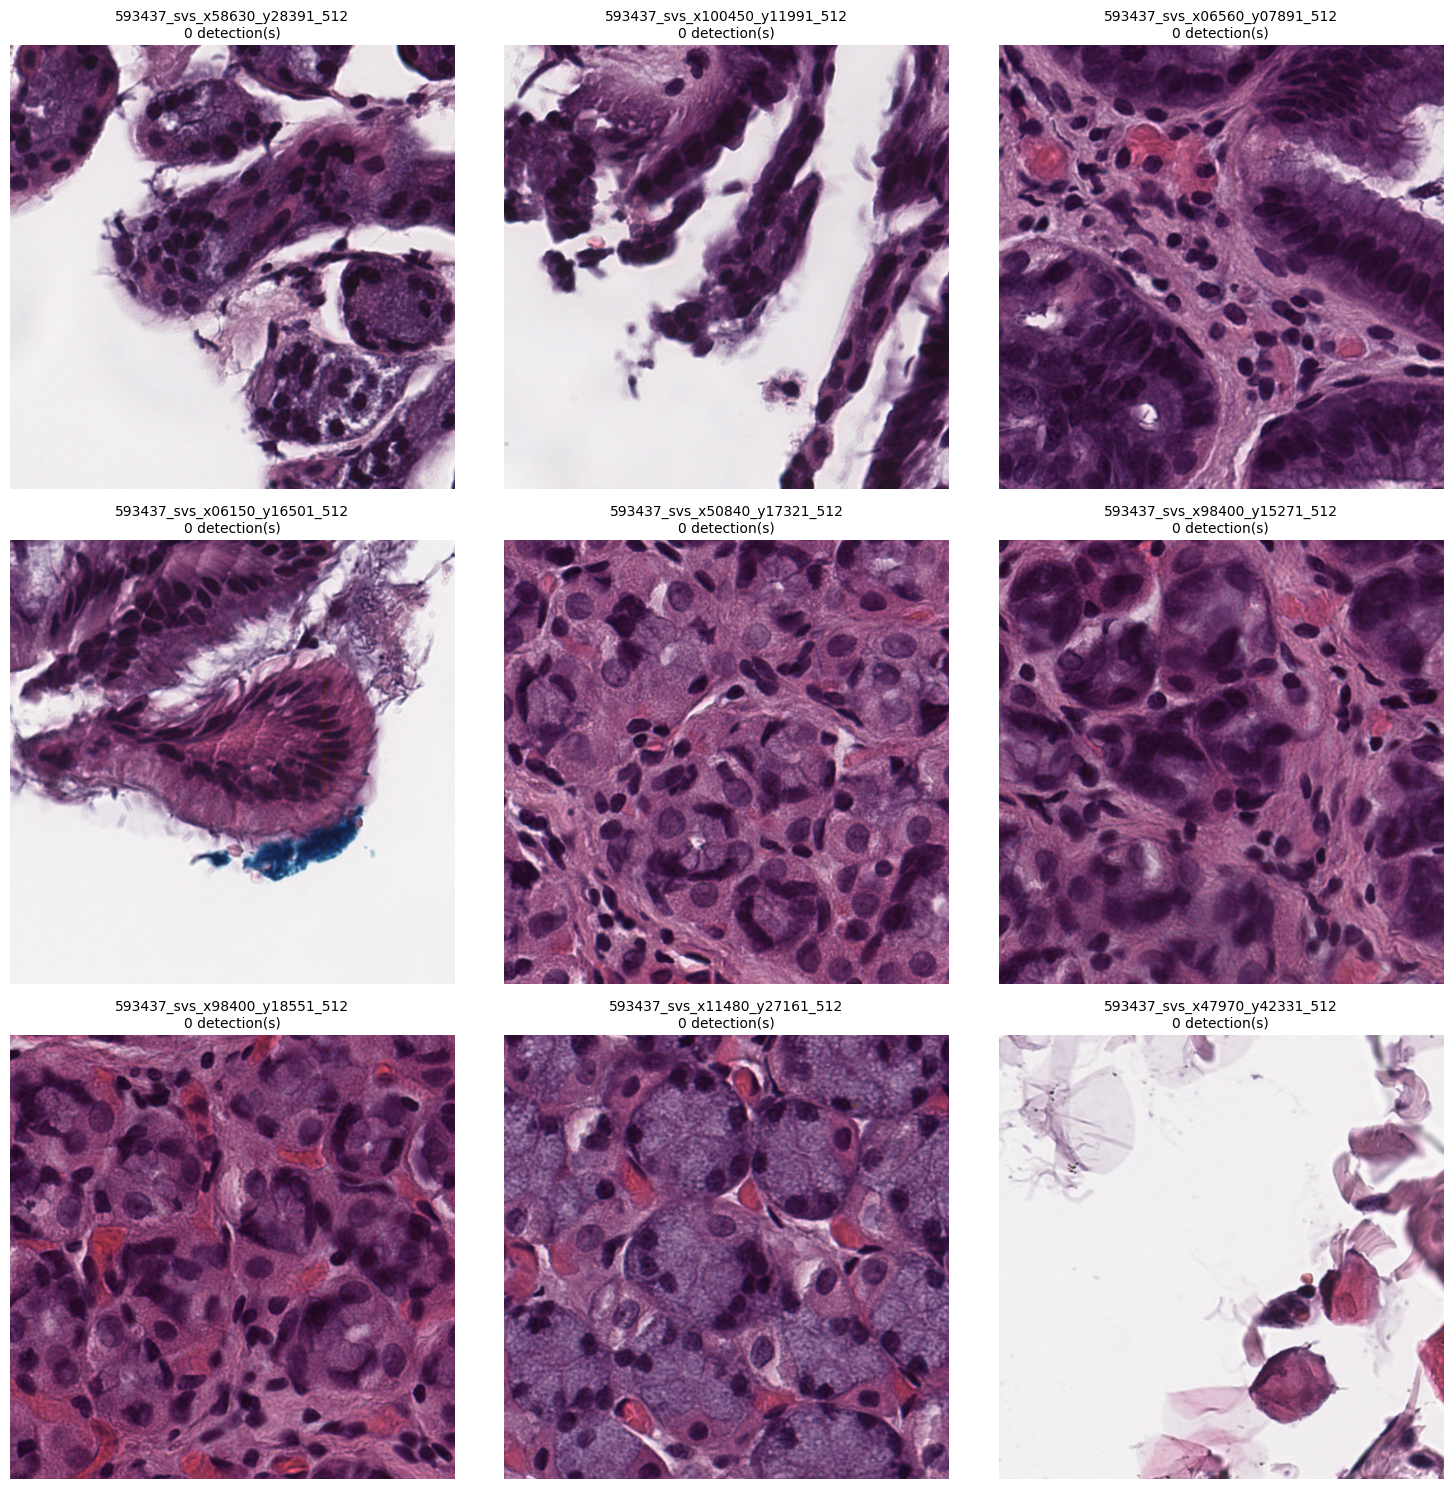

✓ Predictions saved as 'test_predictions.png'


In [14]:
def visualize_predictions(num_samples=6, conf_threshold=0.25):
    """
    Visualize predictions on test samples
    """
    test_images = list((OUTPUT_DIR / 'images' / 'test').glob('*.png'))
    samples = random.sample(test_images, min(num_samples, len(test_images)))
    
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = axes.flatten() if rows > 1 else [axes] if rows == 1 else axes
    
    for idx, img_path in enumerate(samples):
        # Run inference
        results = best_model.predict(str(img_path), conf=conf_threshold, verbose=False)
        
        # Get annotated image
        annotated = results[0].plot()
        annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        
        # Count detections
        num_detections = len(results[0].boxes)
        
        axes[idx].imshow(annotated)
        axes[idx].set_title(f"{img_path.stem}\n{num_detections} detection(s)", fontsize=10)
        axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Predictions saved as 'test_predictions.png'")

visualize_predictions(num_samples=9, conf_threshold=0.25)

## 9. Inference on New Images

In [15]:
def predict_on_patch(image_path, conf_threshold=0.25, iou_threshold=0.15):
    """
    Run inference on a single patch
    
    Args:
        image_path: Path to image
        conf_threshold: Confidence threshold for detections
        iou_threshold: IoU threshold for NMS
    
    Returns:
        Dictionary with detection results
    """
    results = best_model.predict(
        image_path,
        conf=conf_threshold,
        iou=iou_threshold,
        verbose=False
    )
    
    detections = []
    for box in results[0].boxes:
        detections.append({
            'bbox': box.xywh[0].cpu().numpy(),  # [x_center, y_center, width, height]
            'confidence': float(box.conf[0]),
            'class': int(box.cls[0])
        })
    
    return {
        'image_path': image_path,
        'num_detections': len(detections),
        'detections': detections,
        'annotated_image': results[0].plot()
    }

# Example usage
test_image = list((OUTPUT_DIR / 'images' / 'test').glob('*.png'))[0]
result = predict_on_patch(str(test_image))

print(f"\nPrediction on {test_image.name}:")
print(f"  Number of H. pylori detected: {result['num_detections']}")
for i, det in enumerate(result['detections']):
    print(f"  Detection {i+1}: confidence={det['confidence']:.3f}")


Prediction on 593437_svs_x12300_y25111_512.png:
  Number of H. pylori detected: 0


## 10. Calculate Detailed Metrics with DIoU

In [16]:
def calculate_diou(box1, box2):
    """
    Calculate Distance-IoU between two bounding boxes
    
    Args:
        box1, box2: [x_center, y_center, width, height] in normalized coordinates
    
    Returns:
        DIoU value
    """
    x1_c, y1_c, w1, h1 = box1
    x2_c, y2_c, w2, h2 = box2
    
    # Convert to corner coordinates
    x1_min, y1_min = x1_c - w1/2, y1_c - h1/2
    x1_max, y1_max = x1_c + w1/2, y1_c + h1/2
    x2_min, y2_min = x2_c - w2/2, y2_c - h2/2
    x2_max, y2_max = x2_c + w2/2, y2_c + h2/2
    
    # Calculate intersection
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y1_max)
    
    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)
    
    # Calculate union
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - inter_area
    
    # Calculate IoU
    iou = inter_area / (union_area + 1e-6)
    
    # Calculate center distance
    center_dist = np.sqrt((x1_c - x2_c)**2 + (y1_c - y2_c)**2)
    
    # Calculate diagonal of smallest enclosing box
    c_x_min = min(x1_min, x2_min)
    c_y_min = min(y1_min, y2_min)
    c_x_max = max(x1_max, x2_max)
    c_y_max = max(y1_max, y2_max)
    c_diag = np.sqrt((c_x_max - c_x_min)**2 + (c_y_max - c_y_min)**2)
    
    # Calculate DIoU
    diou = iou - (center_dist**2) / (c_diag**2 + 1e-6)
    
    return diou

def evaluate_with_diou(diou_threshold=0.15):
    """
    Evaluate model using DIoU metric as per the paper
    """
    test_images = list((OUTPUT_DIR / 'images' / 'test').glob('*.png'))
    
    total_gt = 0
    total_pred = 0
    true_positives = 0
    
    for img_path in tqdm(test_images, desc="Evaluating with DIoU"):
        # Load ground truth
        label_path = OUTPUT_DIR / 'labels' / 'test' / f"{img_path.stem}.txt"
        gt_boxes = []
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        gt_boxes.append([float(x) for x in parts[1:5]])
        
        # Get predictions
        results = best_model.predict(str(img_path), conf=0.25, verbose=False)
        pred_boxes = []
        for box in results[0].boxes:
            xywh = box.xywhn[0].cpu().numpy()  # Normalized coordinates
            pred_boxes.append(xywh.tolist())
        
        total_gt += len(gt_boxes)
        total_pred += len(pred_boxes)
        
        # Match predictions to ground truth using DIoU
        matched_gt = set()
        for pred_box in pred_boxes:
            best_diou = -1
            best_gt_idx = -1
            
            for gt_idx, gt_box in enumerate(gt_boxes):
                if gt_idx in matched_gt:
                    continue
                
                diou = calculate_diou(pred_box, gt_box)
                if diou > best_diou:
                    best_diou = diou
                    best_gt_idx = gt_idx
            
            if best_diou >= diou_threshold:
                true_positives += 1
                matched_gt.add(best_gt_idx)
    
    # Calculate metrics
    precision = true_positives / total_pred if total_pred > 0 else 0
    recall = true_positives / total_gt if total_gt > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print("\n" + "="*60)
    print(f"EVALUATION RESULTS (DIoU threshold = {diou_threshold})")
    print("="*60)
    print(f"Total ground truth boxes: {total_gt}")
    print(f"Total predicted boxes: {total_pred}")
    print(f"True positives: {true_positives}")
    print(f"\nPrecision: {precision:.2%}")
    print(f"Recall: {recall:.2%}")
    print(f"F1 Score: {f1:.2%}")
    print("="*60)
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'total_gt': total_gt,
        'total_pred': total_pred,
        'true_positives': true_positives
    }

# Evaluate with DIoU threshold of 0.15 as per your paper
diou_metrics = evaluate_with_diou(diou_threshold=0.15)

Evaluating with DIoU: 100%|███████████████████| 391/391 [00:10<00:00, 39.07it/s]


EVALUATION RESULTS (DIoU threshold = 0.15)
Total ground truth boxes: 60
Total predicted boxes: 31
True positives: 28

Precision: 90.32%
Recall: 46.67%
F1 Score: 61.54%


## 11. Export Model for Deployment

In [17]:
# Export to ONNX format for deployment
best_model.export(format='onnx', dynamic=False, simplify=True)

print("✓ Model exported to ONNX format for deployment")
print(f"  Location: runs/hpylori/yolo11x_training/weights/best.onnx")

Ultralytics 8.3.229 🚀 Python-3.10.19 torch-2.9.1+cu128 CPU (Intel Xeon Silver 4208 CPU @ 2.10GHz)

PyTorch: starting from 'runs/hpylori/yolo11x_training/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 5, 5376) (109.1 MB)

ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.74...
ONNX: export success ✅ 7.3s, saved as 'runs/hpylori/yolo11x_training/weights/best.onnx' (217.1 MB)

Export complete (8.8s)
Results saved to /home/biopsy_gregorova/hpylori_project/YOLO_imp/data/runs/hpylori/yolo11x_training/weights
Predict:         yolo predict task=detect model=runs/hpylori/yolo11x_training/weights/best.onnx imgsz=512  
Validate:        yolo val task=detect model=runs/hpylori/yolo11x_training/weights/best.onnx imgsz=512 data=yolo_dataset/data.yaml  
Visualize:       https://netron.app
✓ Model exported to ONNX format for deployment
  Location: runs/hpylori/yolo11x_training/weights/best.onnx


## 12. Summary and Next Steps

In [18]:
print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"\nDataset Statistics:")
print(f"  Total patches: {len(dataset_info['all_patches'])}")
print(f"  Positive patches: {len(dataset_info['positive_patches'])}")
print(f"  Total bounding boxes: {dataset_info['total_bboxes']}")

print(f"\nModel Performance (Test Set):")
print(f"  Precision (DIoU≥0.15): {diou_metrics['precision']:.2%}")
print(f"  Recall (DIoU≥0.15): {diou_metrics['recall']:.2%}")
print(f"  F1 Score: {diou_metrics['f1']:.2%}")

print(f"\nModel Artifacts:")
print(f"  Best weights: runs/hpylori/yolo11x_training/weights/best.pt")
print(f"  ONNX export: runs/hpylori/yolo11x_training/weights/best.onnx")
print(f"  Training plots: runs/hpylori/yolo11x_training/")

print(f"\nNext Steps:")
print(f"  1. Review training plots for convergence")
print(f"  2. Adjust hyperparameters if needed")
print(f"  3. Consider active learning loop to improve annotations")
print(f"  4. Integrate with whole slide image processing pipeline")
print(f"  5. Deploy model for pathologist assistance")
print("="*70)


TRAINING SUMMARY

Dataset Statistics:
  Total patches: 2602
  Positive patches: 310
  Total bounding boxes: 401

Model Performance (Test Set):
  Precision (DIoU≥0.15): 90.32%
  Recall (DIoU≥0.15): 46.67%
  F1 Score: 61.54%

Model Artifacts:
  Best weights: runs/hpylori/yolo11x_training/weights/best.pt
  ONNX export: runs/hpylori/yolo11x_training/weights/best.onnx
  Training plots: runs/hpylori/yolo11x_training/

Next Steps:
  1. Review training plots for convergence
  2. Adjust hyperparameters if needed
  3. Consider active learning loop to improve annotations
  4. Integrate with whole slide image processing pipeline
  5. Deploy model for pathologist assistance
